# Scenario Comparison Analysis

In [1]:
import json
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os

In [ ]:
wind_opt = "windy" #or "not-windy" or "wind-variability"
config_capacity_mix = "stress" #or "balanced"

base_config_name = f"germany_base_{wind_opt}"
scenario_config_name = f"germany_scenario_{config_capacity_mix}"

cluster = "450"
home = "/home/lucakristin/Desktop/my_pypsa"

---
# Building networks

Build the base network without transmission projects (with 450 clusters and from the `germany_base.yaml` file)

```bash
# Build the network (dry run)
snakemake -n --cores 6 "resources/germany_base/networks/base_s_450_elec_.nc" --configfile config/config.germany_base.yaml

# Solve the base network -> for line loads
snakemake -n -call solve_elec_networks --configfile config/config.germany_base.yaml
```

## 2. Create scenario network 

In [ ]:
# caution!! does not work like this 
!python ../create_germany_scenario.py --base-network-path {base_network_path_unsolved} --capacity-mix-name {config_capacity_mix} --home {home}

Loading scenario config from: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/config/scenario_configs/germany_scenario.json
Loading base network from: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/resources/germany_base/networks/base_s_450_elec_.nc
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks
INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to '/home/lucakristin/Desktop/my_pypsa/pypsa-eur/resources/germany_base/networks/base_s_450_elec_.nc contains: carriers, generators, stores, loads, links, lines, sub_networks, buses
Exported base network without extendable lines to /home/lucakristin/Desktop/my_pypsa/pypsa-eur/resources/germany_base/networks/base_s_450_elec_.nc
--- Applying modifications ---
Removing capacity from zero-share carriers ['coal', 'lignite', 'OCGT', 'offwind-dc']: 45921.72 MW
Current total capacity of selected

## 3. Load unsolved networks to see modifications

In [ ]:
# Load the unsolved base network to compare initial capacities
base_network_path_unsolved = f"{home}/pypsa-eur/resources/{base_config_name}/networks/base_s_{cluster}_elec_.nc"
n_base_unsolved = pypsa.Network(base_network_path_unsolved)

# --- Load Scenario Network ---
scenario_network_path_unsolved = f"{home}/pypsa-eur/resources/{scenario_config_name}/networks/base_s_{cluster}_elec_.nc"
n_scenario_unsolved = pypsa.Network(scenario_network_path_unsolved, name="Scenario Network")

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks


In [16]:
n_base_unsolved.summary()

AttributeError: 'Network' object has no attribute 'summary'

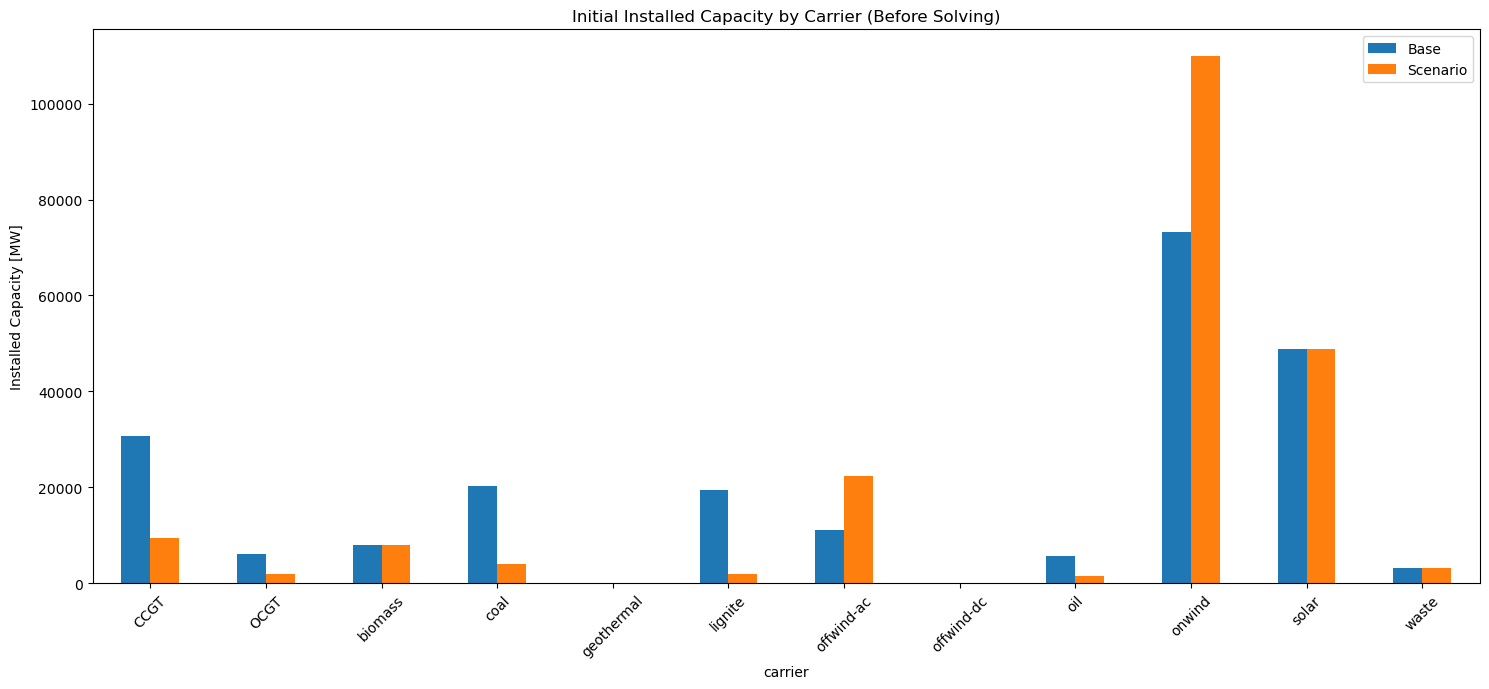

In [197]:
### plot initial capacities by carrier for both networks (before solving)
p_nom_base = n_base_unsolved.generators.groupby("carrier").p_nom.sum()
p_nom_scenario = n_scenario_unsolved.generators.groupby("carrier").p_nom.sum()

df = pd.DataFrame({
    "Base": p_nom_base,
    "Scenario": p_nom_scenario
}).dropna()

df.plot(kind="bar", figsize=(15, 7), rot=45)
plt.ylabel("Installed Capacity [MW]")
plt.title("Initial Installed Capacity by Carrier (Before Solving)")
plt.tight_layout()
plt.show()

In [224]:
# Capacity share by generator carrier for the scenario network
carrier_capacity = n_base_unsolved.generators.groupby("carrier").p_nom.sum()
carrier_capacity_pct = 100 * carrier_capacity / carrier_capacity.sum()
print(base_config_name)
print("Capacity share by carrier (% of total installed generator capacity):")
print(carrier_capacity_pct.sort_values(ascending=False).round(2).astype(str) + "%")

germany_base
Capacity share by carrier (% of total installed generator capacity):
carrier
onwind        32.33%
solar          21.5%
CCGT          13.57%
coal           8.97%
lignite        8.58%
offwind-ac     4.92%
biomass        3.54%
OCGT           2.69%
oil            2.51%
waste          1.38%
geothermal     0.01%
offwind-dc      0.0%
Name: p_nom, dtype: object


In [225]:
# Capacity share by generator carrier for the scenario network
carrier_capacity = n_scenario_unsolved.generators.groupby("carrier").p_nom.sum()
carrier_capacity_pct = 100 * carrier_capacity / carrier_capacity.sum()
print(scenario_config_name)
print("Capacity share by carrier (% of total installed generator capacity):")
print(carrier_capacity_pct.sort_values(ascending=False).round(2).astype(str) + "%")

germany_scenario_lines_extendable
Capacity share by carrier (% of total installed generator capacity):
carrier
onwind        52.16%
solar         23.13%
offwind-ac    10.59%
CCGT           4.42%
biomass         3.8%
coal           1.85%
waste          1.48%
lignite        0.93%
OCGT           0.91%
oil            0.71%
geothermal     0.01%
offwind-dc      0.0%
Name: p_nom, dtype: object


---
# Solving networks

## 1. Check if config.yaml exists before solving 

In [200]:
# Check that a matching scenario config file exists before creating the network.
scenario_yaml_path = f"{home}/pypsa-eur/config/config.{scenario_config_name}.yaml"
if not os.path.isfile(scenario_yaml_path):
    raise FileNotFoundError(
        f"Missing scenario config file: {scenario_yaml_path}\n"
        f"Expected a file named config.{scenario_config_name}.yaml in pypsa-eur/config/."
    )
print(f"Found scenario config: {scenario_yaml_path}")

Found scenario config: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/config/config.germany_scenario_1.yaml


## 2. Solve the network -> for line loads
```bash
snakemake -n -call solve_elec_networks --configfile config/config.germany_scenario.yaml
```

#### Unlock command

```bash
cd pypsa-eur && conda activate pypsa-eur && snakemake -call solve_elec_networks --configfile config/config.germany_scenario_1.yaml --unlock
```

```
Using workflow specific profile profiles/default for setting default command line arguments.
Config file config/config.default.yaml is extended by additional config specified via the command line.
Config file config/plotting.default.yaml is extended by additional config specified via the command line.
Unlocked working directory.
```

## 3. Load solved networks

In [226]:
# --- Load Base Network ---
base_network_path = f"{home}/pypsa-eur/results/{base_config_name}/networks/base_s_{cluster}_elec_.nc"
n_base = pypsa.Network(base_network_path, name="Base Network")
n_base.name = "Base Network"

# --- Load Scenario Network ---
scenario_network_path = f"{home}/pypsa-eur/results/{scenario_config_name}/networks/base_s_{cluster}_elec_.nc"
n_scenario = pypsa.Network(scenario_network_path, name="Scenario Network")
n_scenario.name = "Scenario Network"

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks
